# 260410-2: 최적화(Optimization) — Optimizer와 Scheduler 직접 구현하기

이번 실습에서는 딥러닝 학습에 사용되는 **Optimizer**와 **Learning Rate Scheduler**의 내부 동작을 직접 구현합니다.

## 학습 목표
- **BaseOptimizer** 추상 클래스를 기반으로 SGD, SGD+Momentum, Adam을 직접 구현
- 각 optimizer의 **update rule**을 수식과 코드로 이해하기
- Learning Rate Scheduler (StepLR, CosineAnnealing, ExponentialLR)를 직접 구현
- 직접 구현한 optimizer/scheduler가 PyTorch 내장과 동일하게 동작하는지 검증
- 다양한 optimizer/scheduler 조합의 학습 양상 비교

## 구성
1. 환경 설정 및 데이터 로딩
2. BaseOptimizer 클래스 이해
3. Optimizer 구현: SGD → SGD+Momentum → Adam
4. Optimizer 비교 실험
5. Scheduler 구현: StepLR → CosineAnnealingLR → ExponentialLR
6. Scheduler 비교 실험

### Recap: 오전 강의 핵심

> **Optimization + Regularization** — Optimization 파트

| 개념 | 핵심 |
|------|------|
| **Gradient Descent** | $\theta \leftarrow \theta - \alpha \cdot g$ — gradient 방향으로 파라미터 업데이트 |
| **Mini-batch SGD** | 전체 데이터 대신 일부(mini-batch)로 gradient 추정 → 효율적 |
| **Noise 줄이기** | Sample-wise: batch size ↑ / Time-wise: momentum (EWMA) |
| **Momentum** | 과거 gradient를 누적 → 일관된 방향으로 가속 |
| **Adam** | Momentum + RMSProp — adaptive learning rate + momentum |
| **LR Scheduling** | 학습 후반에 LR을 줄여 세밀하게 수렴 |

이번 실습에서는 **SGD, Momentum, Adam을 직접 구현**하고, LR Scheduler를 적용해봅니다.

In [1]:
# Colab environment check
import sys

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    import subprocess
    gpu_info = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
    if gpu_info.returncode == 0:
        print('GPU available:')
        print(gpu_info.stdout.split('\n')[8])
    else:
        print('No GPU detected. Go to Runtime > Change runtime type > GPU')
    print('Colab detected. Ready to go!')
else:
    print('Running locally (not Colab)')

GPU available:
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
Colab detected. Ready to go!


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import copy
import math

%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [3]:
# 데이터 로딩 (Lab 1과 동일)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
train_set, val_set = torch.utils.data.random_split(trainset, [45000, 5000],
                                                     generator=torch.Generator().manual_seed(42))
train_loader = DataLoader(train_set, batch_size=256, shuffle=True)
val_loader = DataLoader(val_set, batch_size=256, shuffle=False)

# 모델 정의 (Lab 1의 LinearClassifier)
class LinearClassifier(nn.Module):
    def __init__(self, input_dim=3*32*32, num_classes=10):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(input_dim, num_classes)
    def forward(self, x):
        return self.fc(self.flatten(x))

def evaluate(model, data_loader, device):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            _, predicted = torch.max(model(images), 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return correct / total

criterion = nn.CrossEntropyLoss()

100%|██████████| 170M/170M [00:05<00:00, 33.0MB/s]


## 2. BaseOptimizer 클래스

아래는 모든 optimizer가 공유하는 기본 구조입니다. PyTorch의 `torch.optim.Optimizer`도 비슷한 구조를 가지고 있습니다.

핵심 인터페이스:
- `zero_grad()`: 모든 파라미터의 gradient를 0으로 초기화
- `step()`: 파라미터를 업데이트 (각 optimizer마다 다른 update rule)

```
┌─────────────────────────────────────────────────────┐
│  BaseOptimizer                                      │
│  ├── params: 학습할 파라미터 리스트                     │
│  ├── lr: learning rate                              │
│  ├── state: 파라미터별 상태 (velocity, moment 등)      │
│  ├── zero_grad(): gradient 초기화                    │
│  └── step(): 파라미터 업데이트 ← 서브클래스에서 구현     │
│       ├── MySGD:         θ -= lr * g                │
│       ├── MySGDMomentum: v = μv + g; θ -= lr * v   │
│       └── MyAdam:        m,v 업데이트 → θ 업데이트    │
└─────────────────────────────────────────────────────┘
```

In [4]:
class BaseOptimizer:
    """모든 커스텀 optimizer의 기본 클래스"""

    def __init__(self, params, lr=0.01):
        self.params = list(params)
        self.lr = lr
        # 각 파라미터에 대한 상태(state)를 저장하는 딕셔너리
        # 예: velocity, 1st moment, 2nd moment 등
        self.state = {id(p): {} for p in self.params}

    def zero_grad(self):
        """모든 파라미터의 gradient를 0으로 초기화"""
        for p in self.params:
            if p.grad is not None:
                p.grad.zero_()

    def step(self):
        """파라미터 업데이트 — 서브클래스에서 구현"""
        raise NotImplementedError

## 3. Optimizer 구현

### 3-1. Vanilla SGD (Stochastic Gradient Descent)

가장 기본적인 optimizer입니다. 현재 gradient 방향으로 learning rate만큼 이동합니다.

$$\theta_{t+1} = \theta_t - \alpha \cdot g_t$$

- $\theta$: 파라미터 (weight, bias)
- $\alpha$: learning rate
- $g_t$: 현재 gradient

In [6]:
class MySGD(BaseOptimizer):
    """Vanilla SGD optimizer"""

    def __init__(self, params, lr=0.01):
        super().__init__(params, lr)

    def step(self):
        """
        Vanilla SGD update를 수행합니다.
        각 파라미터 p에 대해: p = p - lr * p.grad

        Hint: torch.no_grad() 블록 안에서 in-place 연산(sub_)을 사용하세요.
        """
        with torch.no_grad():
            for p in self.params:
                if p.grad is None:
                    continue
                ############################################################
                # TODO 1: Vanilla SGD update를 구현하세요 (~1줄)             #
                # θ = θ - lr * gradient                                    #
                ############################################################
                p.sub_(self.lr * p.grad)
                ############################################################
                #                     END OF YOUR CODE                     #
                ############################################################

In [7]:
# 검증: torch.optim.SGD와 비교
torch.manual_seed(42)
model_my = LinearClassifier().to(device)
model_pt = copy.deepcopy(model_my)

opt_my = MySGD(model_my.parameters(), lr=0.01)
opt_pt = optim.SGD(model_pt.parameters(), lr=0.01)

for i, (images, labels) in enumerate(train_loader):
    if i >= 3: break
    images, labels = images.to(device), labels.to(device)
    for m, o in [(model_my, opt_my), (model_pt, opt_pt)]:
        o.zero_grad()
        criterion(m(images), labels).backward()
        o.step()

max_diff = max((p1-p2).abs().max().item() for p1,p2 in zip(model_my.parameters(), model_pt.parameters()))
print(f'MySGD vs torch.optim.SGD max param diff: {max_diff:.2e}')
# 예상: < 1e-7

MySGD vs torch.optim.SGD max param diff: 1.86e-09


### 3-2. SGD with Momentum

Vanilla SGD는 gradient가 noisy하면 지그재그로 움직입니다. **Momentum**은 과거의 이동 방향을 **velocity**에 누적하여, 일관된 방향으로 가속합니다.

$$v_t = \mu \cdot v_{t-1} + g_t$$
$$\theta_{t+1} = \theta_t - \alpha \cdot v_t$$

- $v_t$: velocity (누적된 이동 방향, 초기값 0)
- $\mu$: momentum 계수 (보통 0.9)

직관: **공이 언덕을 굴러 내려가는 것** — 같은 방향이 계속되면 속도가 붙고, 방향이 바뀌면 감속합니다.

In [9]:
class MySGDMomentum(BaseOptimizer):
    """SGD with Momentum optimizer"""

    def __init__(self, params, lr=0.01, momentum=0.9):
        super().__init__(params, lr)
        self.momentum = momentum
        # 각 파라미터의 velocity를 state에 초기화
        for p in self.params:
            self.state[id(p)]['velocity'] = torch.zeros_like(p)

    def step(self):
        """
        Momentum update를 수행합니다.
        각 파라미터 p에 대해:
          v = momentum * v + p.grad
          p = p - lr * v

        Hint: self.state[id(p)]['velocity'] 로 velocity에 접근하세요.
              in-place 연산: v.mul_(mu).add_(grad), p.sub_(lr * v)
        """
        with torch.no_grad():
            for p in self.params:
                if p.grad is None:
                    continue
                v = self.state[id(p)]['velocity']
                ############################################################
                # TODO 2: Momentum update를 구현하세요 (~2줄)                #
                # v = momentum * v + gradient                              #
                # p = p - lr * v                                           #
                ############################################################
                v.mul_(self.momentum).add_(p.grad)
                p.sub_(self.lr * v)
                ############################################################
                #                     END OF YOUR CODE                     #
                ############################################################

In [10]:
# 검증: torch.optim.SGD(momentum=0.9)와 비교
torch.manual_seed(42)
model_my = LinearClassifier().to(device)
model_pt = copy.deepcopy(model_my)

opt_my = MySGDMomentum(model_my.parameters(), lr=0.01, momentum=0.9)
opt_pt = optim.SGD(model_pt.parameters(), lr=0.01, momentum=0.9)

for i, (images, labels) in enumerate(train_loader):
    if i >= 3: break
    images, labels = images.to(device), labels.to(device)
    for m, o in [(model_my, opt_my), (model_pt, opt_pt)]:
        o.zero_grad()
        criterion(m(images), labels).backward()
        o.step()

max_diff = max((p1-p2).abs().max().item() for p1,p2 in zip(model_my.parameters(), model_pt.parameters()))
print(f'MySGDMomentum vs torch.optim.SGD(momentum=0.9) max param diff: {max_diff:.2e}')
# 예상: < 1e-7

MySGDMomentum vs torch.optim.SGD(momentum=0.9) max param diff: 1.86e-09


### 3-3. Adam (Adaptive Moment Estimation)

Adam은 현재 가장 널리 사용되는 optimizer입니다. **Momentum** (1st moment)과 **RMSProp** (2nd moment)을 결합합니다.

$$m_t = \beta_1 \cdot m_{t-1} + (1 - \beta_1) \cdot g_t \quad \text{(1st moment: gradient의 이동평균)}$$
$$v_t = \beta_2 \cdot v_{t-1} + (1 - \beta_2) \cdot g_t^2 \quad \text{(2nd moment: gradient 제곱의 이동평균)}$$

초기 step에서 $m$, $v$가 0에 편향되는 것을 보정합니다 (**bias correction**):
$$\hat{m}_t = \frac{m_t}{1 - \beta_1^t}, \quad \hat{v}_t = \frac{v_t}{1 - \beta_2^t}$$

최종 업데이트:
$$\theta_{t+1} = \theta_t - \alpha \cdot \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon}$$

핵심 아이디어: 각 파라미터마다 **적응적으로 learning rate를 조절**합니다.
- gradient가 일관되면 ($\hat{v}$ 작음) → 큰 step
- gradient가 변동이 크면 ($\hat{v}$ 큼) → 작은 step

In [11]:
class MyAdam(BaseOptimizer):
    """Adam optimizer"""

    def __init__(self, params, lr=0.001, betas=(0.9, 0.999), eps=1e-8):
        super().__init__(params, lr)
        self.beta1, self.beta2 = betas
        self.eps = eps
        self.t = 0  # step 카운터 (bias correction에 사용)
        # 각 파라미터의 1st moment (m)와 2nd moment (v) 초기화
        for p in self.params:
            self.state[id(p)]['m'] = torch.zeros_like(p)
            self.state[id(p)]['v'] = torch.zeros_like(p)

    def step(self):
        """
        Adam update를 수행합니다.

        1) step 카운터 증가: self.t += 1
        2) 각 파라미터 p에 대해:
           m = beta1 * m + (1 - beta1) * g          (1st moment update)
           v = beta2 * v + (1 - beta2) * g^2         (2nd moment update)
           m_hat = m / (1 - beta1^t)                  (bias correction)
           v_hat = v / (1 - beta2^t)                  (bias correction)
           p = p - lr * m_hat / (sqrt(v_hat) + eps)   (parameter update)

        Hint: self.state[id(p)]['m'], self.state[id(p)]['v'] 로 접근
              in-place: m.mul_(b1).add_((1-b1) * g)
              거듭제곱: self.beta1 ** self.t
        """
        with torch.no_grad():
            self.t += 1
            for p in self.params:
                if p.grad is None:
                    continue
                g = p.grad
                m = self.state[id(p)]['m']
                v = self.state[id(p)]['v']
                ############################################################
                # TODO 3: Adam update를 구현하세요 (~5줄)                    #
                # 1) m = beta1 * m + (1-beta1) * g                         #
                # 2) v = beta2 * v + (1-beta2) * g^2                       #
                # 3) m_hat = m / (1 - beta1^t)   (bias correction)         #
                # 4) v_hat = v / (1 - beta2^t)   (bias correction)         #
                # 5) p = p - lr * m_hat / (sqrt(v_hat) + eps)              #
                ############################################################
                m.mul_(self.beta1).add_((1 - self.beta1) * g)
                v.mul_(self.beta2).add_((1 - self.beta2) * g * g)
                m_hat = m / (1 - self.beta1 ** self.t)
                v_hat = v / (1 - self.beta2 ** self.t)
                p.sub_(self.lr * m_hat / (v_hat.sqrt() + self.eps))
                ############################################################
                #                     END OF YOUR CODE                     #
                ############################################################

In [12]:
# 검증: torch.optim.Adam과 비교
torch.manual_seed(42)
model_my = LinearClassifier().to(device)
model_pt = copy.deepcopy(model_my)

opt_my = MyAdam(model_my.parameters(), lr=0.001, betas=(0.9, 0.999))
opt_pt = optim.Adam(model_pt.parameters(), lr=0.001, betas=(0.9, 0.999))

for i, (images, labels) in enumerate(train_loader):
    if i >= 5: break
    images, labels = images.to(device), labels.to(device)
    for m, o in [(model_my, opt_my), (model_pt, opt_pt)]:
        o.zero_grad()
        criterion(m(images), labels).backward()
        o.step()

max_diff = max((p1-p2).abs().max().item() for p1,p2 in zip(model_my.parameters(), model_pt.parameters()))
print(f'MyAdam vs torch.optim.Adam max param diff: {max_diff:.2e}')
# 예상: < 1e-6

MyAdam vs torch.optim.Adam max param diff: 7.45e-09


## 4. Optimizer 비교 실험

직접 구현한 3개의 optimizer로 CIFAR-10을 학습하고, 수렴 속도와 성능을 비교합니다.

```
SGD:          θ -= lr * g                    (단순하지만 느림)
SGD+Momentum: v = μv + g; θ -= lr * v        (가속 효과)
Adam:         적응적 lr + momentum             (빠른 수렴)
```

In [13]:
def train_and_record(model, optimizer, train_loader, val_loader, device, num_epochs=10):
    """학습 후 loss/accuracy 기록 반환 (커스텀 optimizer 호환)"""
    criterion = nn.CrossEntropyLoss()
    loss_history, val_acc_history = [], []

    for epoch in range(num_epochs):
        model.train()
        epoch_loss, num_batches = 0.0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = criterion(model(images), labels)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            num_batches += 1
        loss_history.append(epoch_loss / num_batches)
        val_acc_history.append(evaluate(model, val_loader, device))
    return loss_history, val_acc_history

In [14]:
# 동일한 초기 가중치에서 3개 optimizer 비교
torch.manual_seed(42)
base_model = LinearClassifier().to(device)
num_epochs = 10
results = {}

configs = {
    'MySGD':          lambda m: MySGD(m.parameters(), lr=0.01),
    'MySGDMomentum':  lambda m: MySGDMomentum(m.parameters(), lr=0.01, momentum=0.9),
    'MyAdam':         lambda m: MyAdam(m.parameters(), lr=0.001),
}

for name, make_opt in configs.items():
    model_copy = copy.deepcopy(base_model).to(device)
    opt = make_opt(model_copy)
    loss_hist, val_hist = train_and_record(model_copy, opt, train_loader, val_loader, device, num_epochs)
    results[name] = {'loss': loss_hist, 'val_acc': val_hist}
    print(f'{name:18s} → Final Loss: {loss_hist[-1]:.4f}, Val Acc: {val_hist[-1]:.4f}')

MySGD              → Final Loss: 1.6863, Val Acc: 0.4076
MySGDMomentum      → Final Loss: 1.8581, Val Acc: 0.3330
MyAdam             → Final Loss: 1.7020, Val Acc: 0.3736


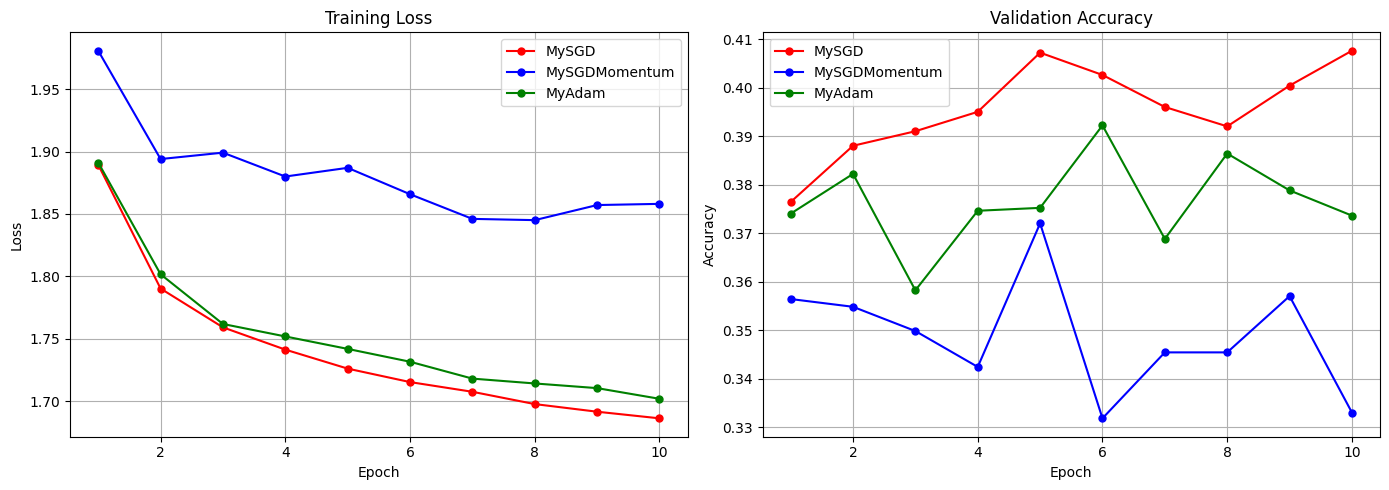

In [15]:
# Optimizer 비교 시각화
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
colors = {'MySGD': 'red', 'MySGDMomentum': 'blue', 'MyAdam': 'green'}
epochs = range(1, num_epochs + 1)

for name, data in results.items():
    ax1.plot(epochs, data['loss'], '-o', color=colors[name], label=name, markersize=5)
    ax2.plot(epochs, data['val_acc'], '-o', color=colors[name], label=name, markersize=5)

ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Training Loss'); ax1.legend(); ax1.grid(True)

ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.set_title('Validation Accuracy'); ax2.legend(); ax2.grid(True)

plt.tight_layout()
plt.show()

### 생각해보기
- 어떤 optimizer가 가장 빨리 수렴하나요?
- Adam이 SGD보다 초기 학습 속도가 빠른 이유는 무엇일까요? (힌트: adaptive learning rate)
- SGD+Momentum의 momentum 계수를 바꾸면 어떻게 될까요?
- 실무에서는 항상 Adam을 쓰면 될까요? (힌트: SGD+Momentum이 최종 성능에서 더 나은 경우도 있음)

## 5. Learning Rate Scheduler 구현

학습 초반에는 큰 learning rate로 빠르게 수렴하고, 후반에는 작은 learning rate로 세밀하게 최적점에 도달하는 것이 좋습니다.

```
┌─────────────────────────────────────────────────────────────┐
│  BaseScheduler                                              │
│  ├── optimizer: lr을 조절할 대상 optimizer                    │
│  ├── base_lr: 초기 learning rate                             │
│  ├── current_epoch: 현재 epoch                              │
│  └── step(): epoch 증가 + lr 업데이트 ← 서브클래스에서 구현    │
│       ├── MyStepLR:            계단식 감소                   │
│       ├── MyExponentialLR:     지수적 감소                   │
│       └── MyCosineAnnealingLR: cosine 곡선 감소             │
└─────────────────────────────────────────────────────────────┘
```

In [16]:
class BaseScheduler:
    """모든 커스텀 scheduler의 기본 클래스"""

    def __init__(self, optimizer):
        # optimizer가 커스텀이든 PyTorch이든 호환되게 처리
        if hasattr(optimizer, 'lr'):
            self.base_lr = optimizer.lr
        else:
            self.base_lr = optimizer.param_groups[0]['lr']
        self.optimizer = optimizer
        self.current_epoch = 0

    def _set_lr(self, new_lr):
        """optimizer의 learning rate를 변경"""
        if hasattr(self.optimizer, 'lr'):
            self.optimizer.lr = new_lr  # 커스텀 optimizer
        else:
            for pg in self.optimizer.param_groups:
                pg['lr'] = new_lr  # PyTorch optimizer

    def get_lr(self):
        """현재 learning rate 반환"""
        if hasattr(self.optimizer, 'lr'):
            return self.optimizer.lr
        return self.optimizer.param_groups[0]['lr']

    def step(self):
        """epoch 증가 + lr 업데이트 — 서브클래스에서 _compute_lr() 구현"""
        self.current_epoch += 1
        new_lr = self._compute_lr()
        self._set_lr(new_lr)

    def _compute_lr(self):
        raise NotImplementedError

### 5-1. StepLR — 계단식 감소

일정 epoch(`step_size`)마다 learning rate를 `gamma`배로 감소시킵니다.

$$\text{lr}_t = \text{lr}_0 \times \gamma^{\lfloor t / \text{step\_size} \rfloor}$$

예: `step_size=5, gamma=0.5`이면 매 5 epoch마다 lr이 절반으로 줄어듭니다.
```
epoch:  1  2  3  4  5 │ 6  7  8  9  10 │ 11 ...
lr:    0.01 ──────────│ 0.005 ─────────│ 0.0025 ...
```

In [17]:
class MyStepLR(BaseScheduler):
    """StepLR scheduler"""

    def __init__(self, optimizer, step_size=5, gamma=0.5):
        super().__init__(optimizer)
        self.step_size = step_size
        self.gamma = gamma

    def _compute_lr(self):
        """
        현재 epoch에 따른 lr을 계산하세요.
        lr = base_lr * gamma^(current_epoch // step_size)

        Hint: self.current_epoch, self.step_size, self.gamma, self.base_lr 사용
        """
        ############################################################
        # TODO 4: StepLR의 lr 계산을 구현하세요 (~1줄)               #
        ############################################################
        return self.base_lr * (self.gamma ** (self.current_epoch // self.step_size))
        ############################################################
        #                     END OF YOUR CODE                     #
        ############################################################

### 5-2. ExponentialLR — 지수적 감소

매 epoch마다 learning rate에 `gamma`를 곱합니다. StepLR보다 부드럽게 감소합니다.

$$\text{lr}_t = \text{lr}_0 \times \gamma^{t}$$

```
epoch:  1       2       3       4       5
lr:    0.0095  0.009025 0.00857 0.00814 0.00773 ...  (gamma=0.95)
```

In [18]:
class MyExponentialLR(BaseScheduler):
    """ExponentialLR scheduler"""

    def __init__(self, optimizer, gamma=0.95):
        super().__init__(optimizer)
        self.gamma = gamma

    def _compute_lr(self):
        """
        현재 epoch에 따른 lr을 계산하세요.
        lr = base_lr * gamma^current_epoch

        Hint: self.current_epoch, self.gamma, self.base_lr 사용
        """
        ############################################################
        # TODO 5: ExponentialLR의 lr 계산을 구현하세요 (~1줄)         #
        ############################################################
        return self.base_lr * (self.gamma ** self.current_epoch)
        ############################################################
        #                     END OF YOUR CODE                     #
        ############################################################

### 5-3. CosineAnnealingLR — Cosine 곡선 감소

Cosine 함수를 사용하여 learning rate를 부드럽게 감소시킵니다. 최근 가장 많이 사용되는 스케줄러 중 하나입니다.

$$\text{lr}_t = \text{lr}_{\min} + \frac{1}{2}(\text{lr}_0 - \text{lr}_{\min}) \left(1 + \cos\left(\frac{t}{T_{\max}} \cdot \pi\right)\right)$$

- $T_{\max}$: 총 epoch 수 (반 주기)
- $\text{lr}_{\min}$: 최소 learning rate (보통 0)

```
lr │ ╲
   │   ╲                         ← 초반에 빠르게 감소
   │    ╲
   │     ╲_
   │       ╲__                   ← 중반에 완만하게
   │          ╲____
   │               ╲________    ← 후반에 거의 0에 수렴
   └─────────────────────── epoch
```

In [19]:
class MyCosineAnnealingLR(BaseScheduler):
    """CosineAnnealingLR scheduler"""

    def __init__(self, optimizer, T_max=20, eta_min=0):
        super().__init__(optimizer)
        self.T_max = T_max
        self.eta_min = eta_min

    def _compute_lr(self):
        """
        현재 epoch에 따른 lr을 cosine 곡선으로 계산하세요.
        lr = eta_min + 0.5 * (base_lr - eta_min) * (1 + cos(current_epoch / T_max * pi))

        Hint: math.cos(), math.pi 사용
        """
        ############################################################
        # TODO 6: CosineAnnealingLR의 lr 계산을 구현하세요 (~1줄)     #
        ############################################################
        return self.eta_min + 0.5 * (self.base_lr - self.eta_min) * (1 + math.cos(self.current_epoch / self.T_max * math.pi))
        ############################################################
        #                     END OF YOUR CODE                     #
        ############################################################

### 5-4. Scheduler 검증

직접 구현한 scheduler들이 PyTorch 내장과 동일한 lr 곡선을 만드는지 확인합니다.

/tmp/ipykernel_6552/4222358374.py:35: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  sched_pt.step()


MyStepLR vs PyTorch StepLR: max lr diff = 0.00e+00
MyExponentialLR vs PyTorch ExponentialLR: max lr diff = 8.67e-19
MyCosineAnnealingLR vs PyTorch CosineAnnealingLR: max lr diff = 2.60e-18


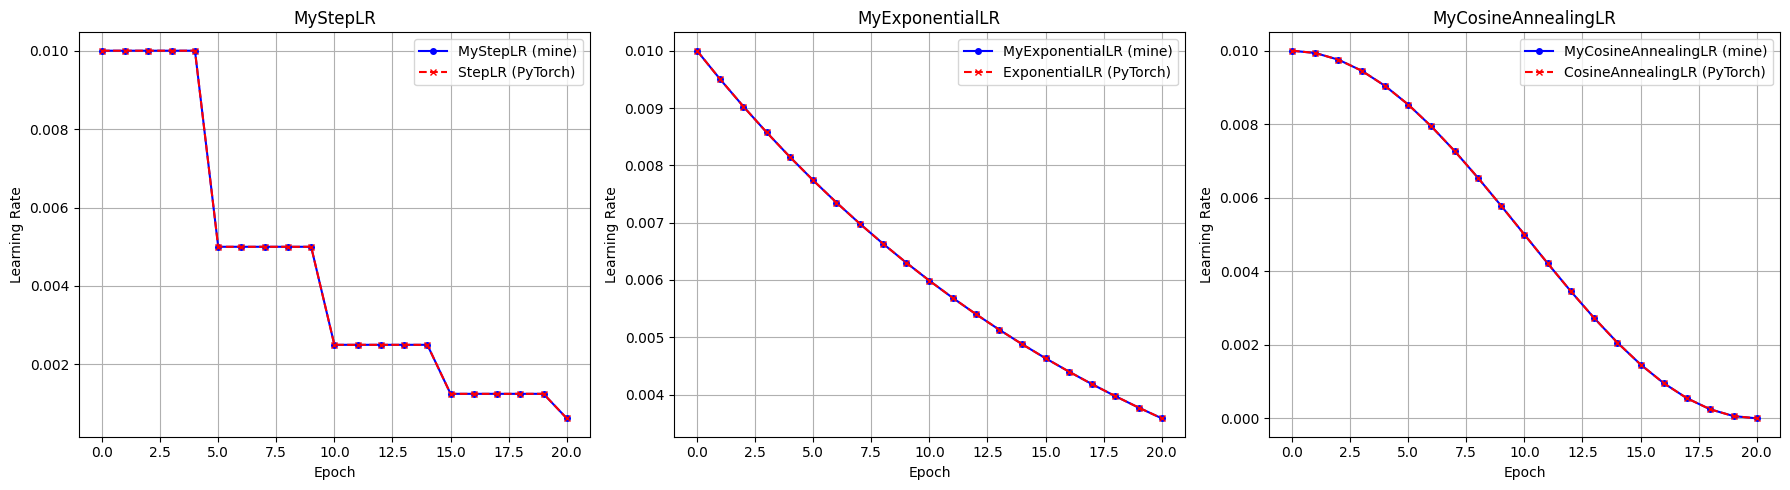

In [20]:
# 3개 scheduler의 lr 곡선을 PyTorch와 비교
total_epochs = 20

schedulers_my = {
    'MyStepLR':             lambda opt: MyStepLR(opt, step_size=5, gamma=0.5),
    'MyExponentialLR':      lambda opt: MyExponentialLR(opt, gamma=0.95),
    'MyCosineAnnealingLR':  lambda opt: MyCosineAnnealingLR(opt, T_max=total_epochs),
}
schedulers_pt = {
    'StepLR':             lambda opt: optim.lr_scheduler.StepLR(opt, step_size=5, gamma=0.5),
    'ExponentialLR':      lambda opt: optim.lr_scheduler.ExponentialLR(opt, gamma=0.95),
    'CosineAnnealingLR':  lambda opt: optim.lr_scheduler.CosineAnnealingLR(opt, T_max=total_epochs),
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors_pair = [('blue', 'red'), ('blue', 'red'), ('blue', 'red')]

for idx, (name_my, make_my) in enumerate(schedulers_my.items()):
    name_pt = list(schedulers_pt.keys())[idx]
    make_pt = list(schedulers_pt.values())[idx]

    # My scheduler
    dummy_opt_my = MySGD([torch.zeros(1, requires_grad=True)], lr=0.01)
    sched_my = make_my(dummy_opt_my)
    lrs_my = [dummy_opt_my.lr]
    for _ in range(total_epochs):
        sched_my.step()
        lrs_my.append(sched_my.get_lr())

    # PyTorch scheduler
    dummy_opt_pt = optim.SGD([torch.zeros(1, requires_grad=True)], lr=0.01)
    sched_pt = make_pt(dummy_opt_pt)
    lrs_pt = [dummy_opt_pt.param_groups[0]['lr']]
    for _ in range(total_epochs):
        sched_pt.step()
        lrs_pt.append(dummy_opt_pt.param_groups[0]['lr'])

    ax = axes[idx]
    ax.plot(range(total_epochs + 1), lrs_my, 'b-o', label=f'{name_my} (mine)', markersize=4)
    ax.plot(range(total_epochs + 1), lrs_pt, 'r--x', label=f'{name_pt} (PyTorch)', markersize=4)
    ax.set_xlabel('Epoch'); ax.set_ylabel('Learning Rate')
    ax.set_title(name_my); ax.legend(); ax.grid(True)

    max_diff = max(abs(a-b) for a,b in zip(lrs_my, lrs_pt))
    print(f'{name_my} vs PyTorch {name_pt}: max lr diff = {max_diff:.2e}')

plt.tight_layout()
plt.show()

## 6. Scheduler 비교 실험

직접 구현한 scheduler들을 실제 학습에 적용하여 효과를 비교합니다.

In [ ]:
# Scheduler 비교: No Scheduler vs StepLR vs Cosine vs Exponential
torch.manual_seed(42)
base_model = LinearClassifier().to(device)
num_epochs_sched = 5
sched_results = {}

configs_sched = {
    'No Scheduler': None,
    'MyStepLR':     lambda opt: MyStepLR(opt, step_size=5, gamma=0.5),
    'MyExponentialLR': lambda opt: MyExponentialLR(opt, gamma=0.95),
    'MyCosineAnnealingLR': lambda opt: MyCosineAnnealingLR(opt, T_max=num_epochs_sched),
}

for name, make_sched in configs_sched.items():
    model_copy = copy.deepcopy(base_model).to(device)
    opt = MySGDMomentum(model_copy.parameters(), lr=0.01, momentum=0.9)
    sched = make_sched(opt) if make_sched else None

    loss_hist, val_hist, lr_hist = [], [], []

    for epoch in range(num_epochs_sched):
        model_copy.train()
        epoch_loss, num_batches = 0.0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            opt.zero_grad()
            loss = criterion(model_copy(images), labels)
            loss.backward()
            opt.step()
            epoch_loss += loss.item()
            num_batches += 1
        loss_hist.append(epoch_loss / num_batches)
        val_hist.append(evaluate(model_copy, val_loader, device))
        lr_hist.append(opt.lr)
        if sched:
            sched.step()

    sched_results[name] = {'loss': loss_hist, 'val_acc': val_hist, 'lr': lr_hist}
    print(f'{name:24s} → Final Loss: {loss_hist[-1]:.4f}, Val Acc: {val_hist[-1]:.4f}')

No Scheduler             → Final Loss: 1.8723, Val Acc: 0.3522
MyStepLR                 → Final Loss: 1.8580, Val Acc: 0.3548
MyExponentialLR          → Final Loss: 1.8261, Val Acc: 0.3742


In [ ]:
# Scheduler 비교 시각화
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors_sched = {'No Scheduler': 'gray', 'MyStepLR': 'red',
                'MyExponentialLR': 'green', 'MyCosineAnnealingLR': 'blue'}
epochs = range(1, num_epochs_sched + 1)

for name, data in sched_results.items():
    c = colors_sched[name]
    axes[0].plot(epochs, data['lr'], '-o', color=c, label=name, markersize=3)
    axes[1].plot(epochs, data['loss'], '-o', color=c, label=name, markersize=3)
    axes[2].plot(epochs, data['val_acc'], '-o', color=c, label=name, markersize=3)

axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Learning Rate')
axes[0].set_title('LR Schedule 비교'); axes[0].legend(); axes[0].grid(True)

axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].set_title('Training Loss'); axes[1].legend(); axes[1].grid(True)

axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Accuracy')
axes[2].set_title('Validation Accuracy'); axes[2].legend(); axes[2].grid(True)

plt.tight_layout()
plt.show()

### 정리

**Optimizer 선택 가이드:**
- **SGD**: 단순하고 해석이 쉬움. 대규모 모델에서 최종 성능이 좋은 경우가 있음
- **SGD + Momentum**: SGD의 수렴 속도를 개선. 대부분의 경우 vanilla SGD보다 좋음
- **Adam**: 빠른 수렴, 하이퍼파라미터 튜닝이 쉬움. 실무의 기본 선택

**Scheduler 선택 가이드:**
- **StepLR**: 구현이 간단하고 직관적. 언제 감소할지 명확
- **ExponentialLR**: 부드럽게 감소. StepLR의 급격한 변화가 싫을 때
- **CosineAnnealingLR**: 최근 가장 인기. Warmup과 함께 사용하면 효과적

> 실무 팁: `torch.optim.lr_scheduler`에는 이 외에도 `ReduceLROnPlateau` (val loss가 개선되지 않으면 감소), `OneCycleLR` (1-cycle policy), `CosineAnnealingWarmRestarts` (주기적 restart) 등 다양한 스케줄러가 있습니다.